---
title: "Practice Activity 2-1: Data Visualization and the Grammar of Graphics"
format:
  html:
    embed-resources: true
---

# Data Visualization Using `plotnine` and the grammar of graphics



## Cars Data

The Palmer Penguins dataset had a variety of column types with which to explore some nice visualizations. The `mtcars` dataset is another popular dataset for doing some simple data work, but does not contain the same types of variables.

Run the following code to load the `mtcars` dataset and explore the observations and variables contained within. To learn more about this dataset check out [this site](https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/mtcars.html)

In [41]:
import statsmodels.api as sm
import pandas as pd

mtcars = sm.datasets.get_rdataset("mtcars", "datasets", cache=True).data
df = pd.DataFrame(mtcars)

In [42]:
df

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2


The statement "the `mtcars` dataset does not contain the same types of variables as the penguins dataset" is a little true and a little false. There are no variables that contain text values, BUT there are variables that it makes sense to consider categorical variables. In most situations, it makes sense to treat the values of categorical variables as text values instead of numeric values.

Some of these variables, like the `cyl` variable, have numeric values that actually make sense as numbers (i.e. the number of cylinders in the engine). However, it doesn't make the most sense to "do math" with this type of variable (e.g. take averages and such) because there are so few different value this can take on AND they're an explicit choice made by the car manufacturer. So, it makes more sense to treat the `cyl` variable as a categorical variable despite it having numeric values.

You will need to keep these kinds of nuances about data in mind as you work with an increasing variety and richness of data, and do more complex things with them

Use the `astype()` method to convert the categorical variables of the `mtcars` (df) dataset to have text values in the code chunk below. We've done one for you!

In [43]:
df["am"] = df["am"].astype(str)

# Convert the other variables below
df["cyl"] = df["cyl"].astype(str)
df["vs"] = df["vs"].astype(str)
df["gear"] = df["gear"].astype(str)
df["carb"] = df["carb"].astype(str)

In [44]:
df

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2


In [45]:
df.dtypes

mpg     float64
cyl         str
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs          str
am          str
gear        str
carb        str
dtype: object

Answer: The values still look like numbers in the table. However, when I check `df.dtypes`, I can see that `cyl`, `vs`, `am`, `gear`, and `carb` are now `str`. This tells me they have been converted to text.

If you print out your new dataset, is it clear that the variables have been converted to text values? If so, how can you tell?

Let's see how `plotnine` treats these variables.


1\. Create side-by-side boxplots of the `mpg` variable by the different values of the `am` variable.

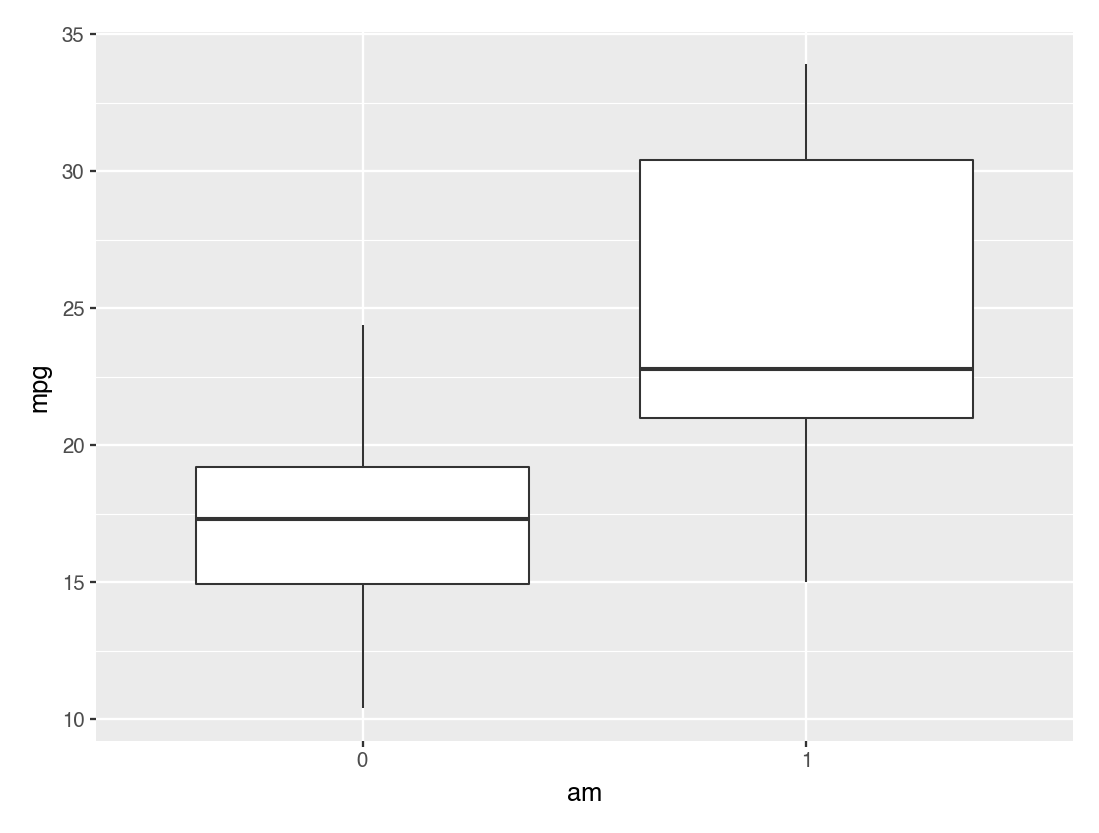

In [46]:
from plotnine import ggplot, aes, geom_boxplot

ggplot(df, aes(x="am", y="mpg")) + geom_boxplot()

2\. What happens if you convert the `am` variable back to float values and then try to create the same plot as in the previous part? Explain the differences between the two plots.

In [47]:
df["am"] = df["am"].astype(float)

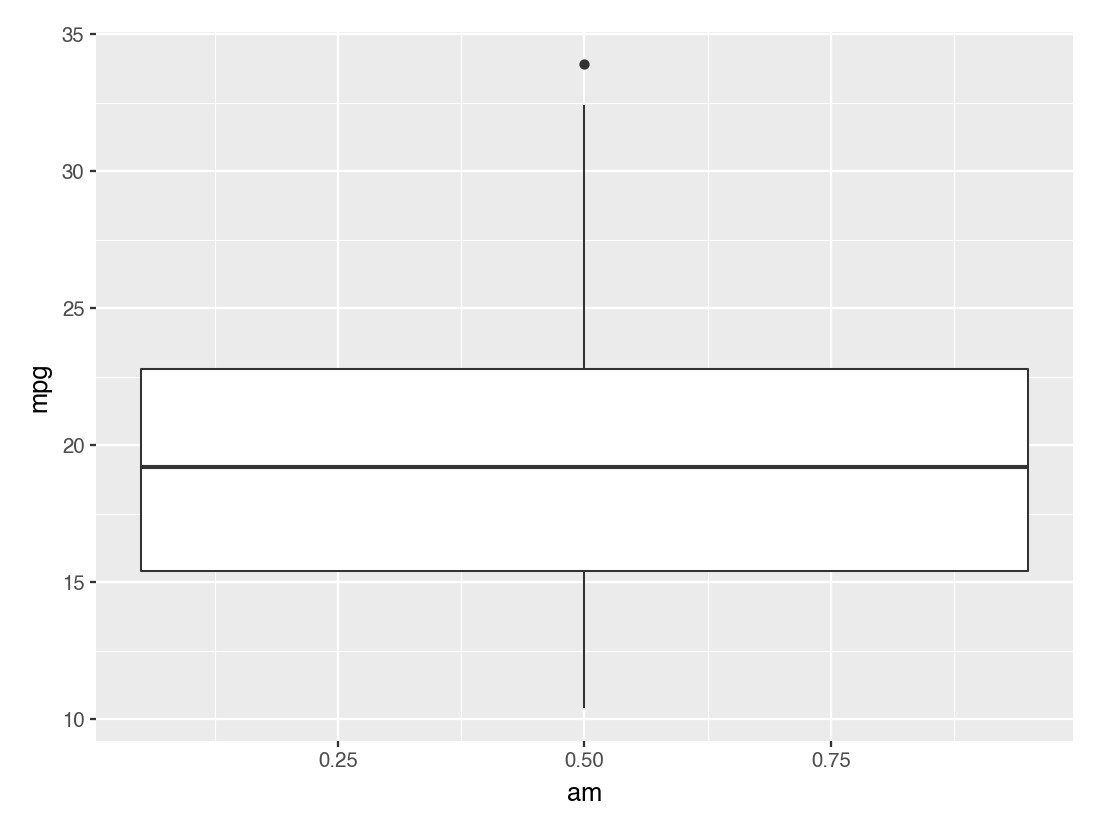

In [48]:
ggplot(df, aes(x="am", y="mpg")) + geom_boxplot()

Answer: After I converted am to float, the plot showed one box instead of two. In the first plot, am was treated as a category, so automatic and manual cars had separate boxes. In the second plot, am was treated as numeric, and the same code put all cars into one box. This means I can no longer compare the two transmission groups in this plot.

3\. Create overlaid histograms of the `hp` variable for the different values of the `cyl` variable.

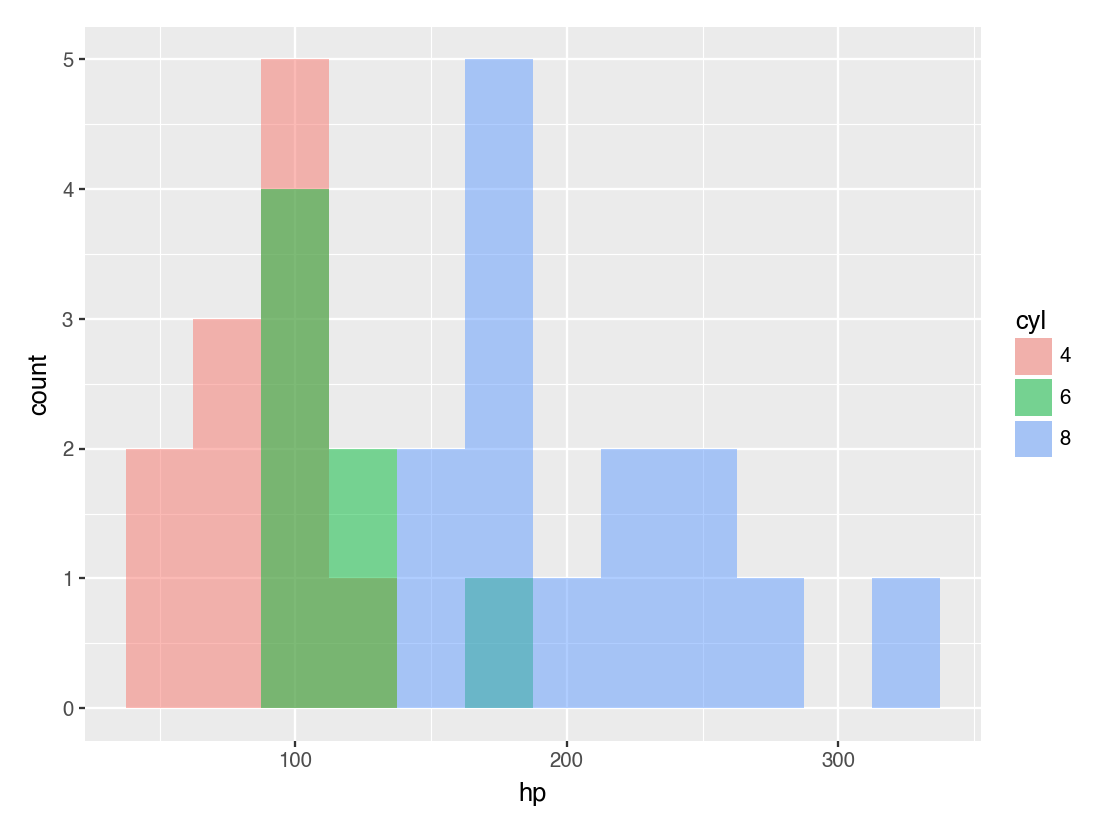

In [49]:
from plotnine import geom_histogram

ggplot(df, aes(x="hp", fill="cyl")) + geom_histogram(binwidth=25, position="identity", alpha=0.5)

4\. What happens if you convert the `cyl` variable back to float values and then try to create the same plot as in the previous part? Explain the differences between the two plots.

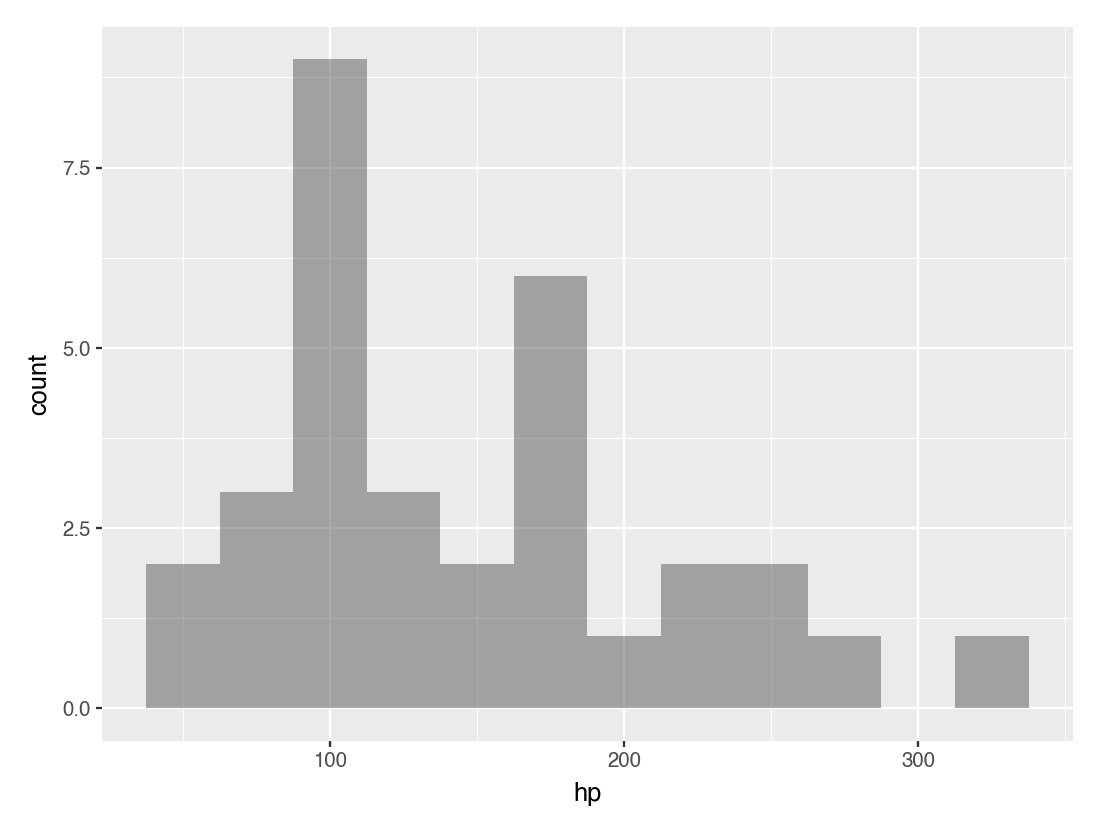

In [50]:
df["cyl"] = df["cyl"].astype(float)

ggplot(df, aes(x="hp", fill="cyl")) + geom_histogram(binwidth=25, position="identity", alpha=0.5)

Answer: After I converted cyl to float, the histogram became gray and the legend disappeared. In the previous plot, different colors showed the 4-, 6-, and 8-cylinder groups separately. In this plot, the same code no longer grouped the cars by cyl, so it showed the horsepower distribution of all cars together. I can no longer compare the cylinder groups by color.

5\. Choose a new `geometry` from the [data-to-viz website](https://www.data-to-viz.com/) or look in the [`plotnine` graph gallery](https://python-graph-gallery.com/plotnine/) for a graph that you'd like to explore using the `mtcars` dataset, and then create that graph. Share your graph with a classmate and discuss it's advantages and disadvantages.

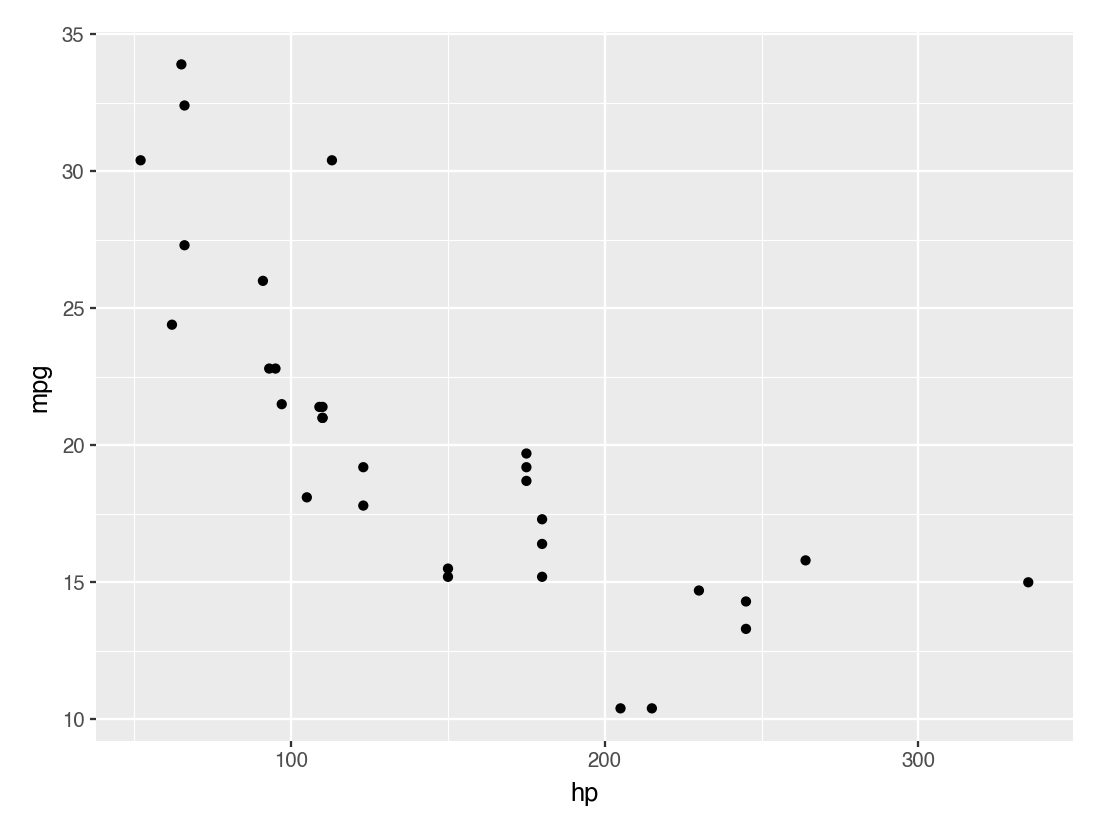

In [51]:
from plotnine import geom_point

ggplot(df, aes(x="hp", y="mpg")) + geom_point()

Answer: I chose a scatterplot to explore the relationship between horsepower and mpg. I can see that cars with higher horsepower generally have lower mpg, meaning they travel fewer miles per gallon of fuel. An advantage is that the plot makes this relationship easy to see. A disadvantage is that some points can overlap, making it hard to tell how many cars are at the same position.

6\. Repeat the previous part for another graph that you'd like to explore using the `mtcars` dataset, and then create that graph. Share your graph with a classmate and discuss it's advantages and disadvantages.

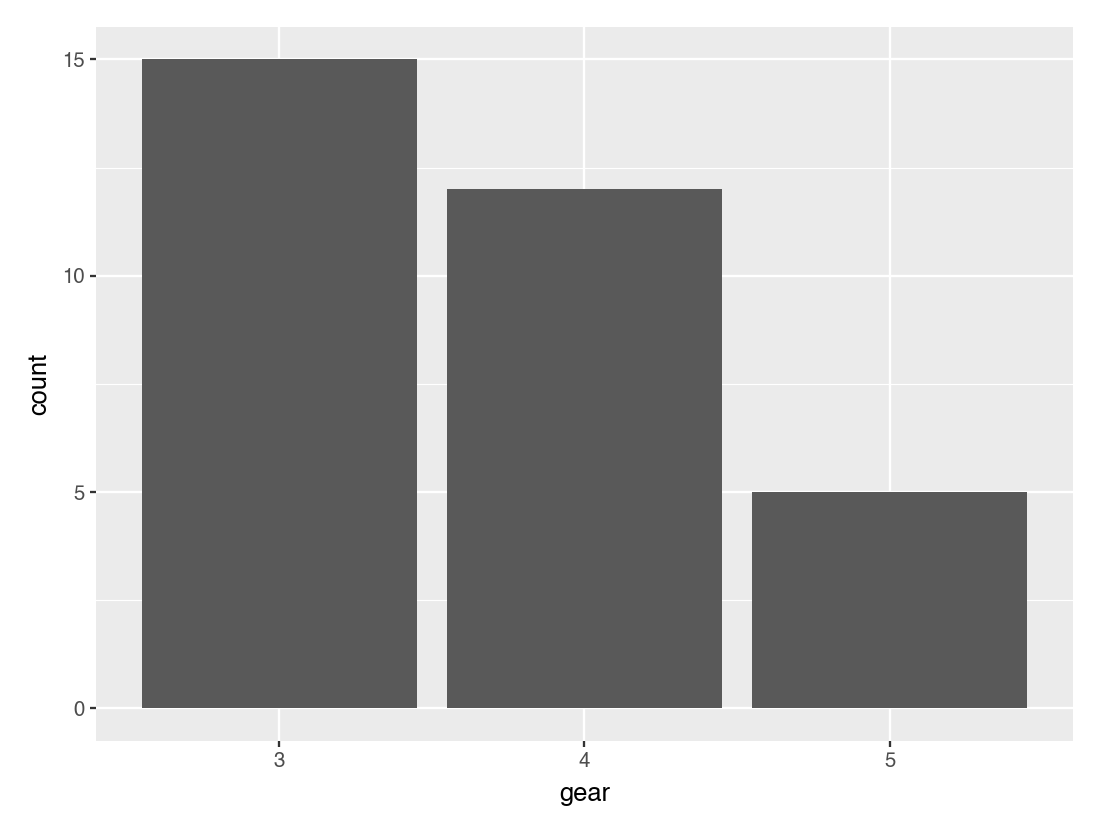

In [52]:
from plotnine import geom_bar

ggplot(df, aes(x="gear")) + geom_bar()

Answer: I chose a bar plot to compare the number of cars with different numbers of gears. In this dataset, 15 cars have 3 gears, 12 have 4 gears, and 5 have 5 gears. An advantage is that the counts are easy to compare. A limitation is that the plot only shows how many cars are in each group, not how the groups differ in mpg or horsepower.

## FEV Data

(You saw this data set in [GSB 518](https://kevin-davisross.quarto.pub/gsb518-notes/hw-09.html#problem-3).) Do non-smokers have better lungs than smokers? One measure of lung function is forced expiratory volume (FEV), the amount of air (in liters) an individual can exhale in the first second of forceful breath. Larger values of FEV are indicative of better functioning lungs. In a study, FEV was measured for a group of 654 subjects, along with whether they smoked and other variables like age (years). [Here is the data.](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/FEV.csv)

[This plot](https://drive.google.com/file/d/1dm7U1cpVpHrbNZrBymOdmtkhMX3U7BwU/view?usp=sharing) was made using `plotly`. Use AI to help reproduce it using `plotnine`. Think in terms of the grammar of graphics and the design of the plot and write prompts like "The x-axis is mapped to Age". It might help to [try the two practice activities in Section 3.6.3 first](https://ds-ml-with-python.github.io/Course-Textbook/02-plotnine.html#try-it-out). (Hint: this is really 3 separate plots. Consider using the `patchworklib` package, which you need to install in Colab space first.)


In [53]:
fev_url = "https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/FEV.csv"

fev = pd.read_csv(fev_url)

fev

,ID,Smoking status,FEV,Height,Age (months)
0,201,non-smoker,2.884,69.0,132
1,202,non-smoker,2.328,64.0,120
2,301,non-smoker,1.708,57.0,108
3,341,non-smoker,3.381,63.0,172
4,351,non-smoker,2.170,58.0,130
...,...,...,...,...,...
649,83841,non-smoker,2.115,50.0,58
650,83901,non-smoker,2.328,60.0,98
651,83951,smoker,3.069,65.0,130
652,83952,non-smoker,1.495,57.0,85


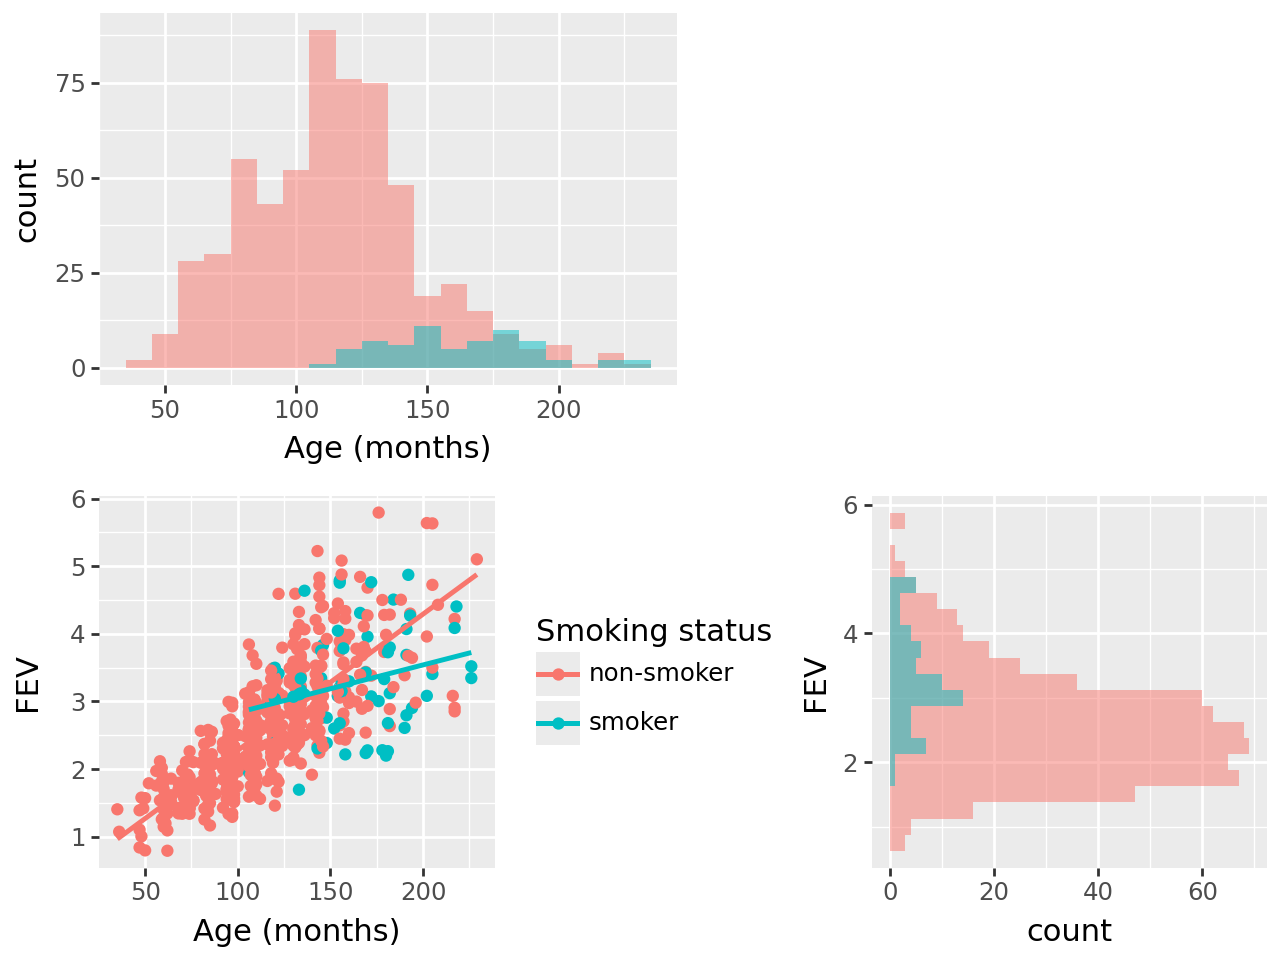

In [54]:
from plotnine import ggplot, aes, geom_point, geom_smooth, geom_histogram, coord_flip, theme
from plotnine.composition import plot_spacer

age_plot = ggplot(fev, aes(x="Age (months)", fill="Smoking status")) + geom_histogram(binwidth=10, position="identity", alpha=0.5) + theme(legend_position="none")

main_plot = ggplot(fev, aes(x="Age (months)", y="FEV", color="Smoking status")) + geom_point() + geom_smooth(method="lm", se=False)

fev_plot = ggplot(fev, aes(x="FEV", fill="Smoking status")) + geom_histogram(binwidth=0.25, position="identity", alpha=0.5) + coord_flip() + theme(legend_position="none")

final_plot = (age_plot | plot_spacer()) / (main_plot | fev_plot)

final_plot

## Olympic Men's Gymnastics Data

[This file](https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv) contains scores from the qualification and final rounds of the Olympic men's gymnastics all around competition from 2008 to 2020. (Thanks to Martin Hsu for scraping this data set.)

1\. Your goal will be to create a graphic which summarizes the distribution of scores across events and years, and any other features you want to add. But first...


This data is in "wide format" in that the scores are spread over six columns.

| Floor score | Pommel score | Rings score | Vault score | Pbar score | Hbar score |
|------------:|-------------:|------------:|------------:|-----------:|-----------:|
|        15.0 |         14.5 |        15.2 |        16.1 |       14.6 |       15.0 |


In order to produce some plots (and work with the grammar of graphics more fully), you might need to reformat the data so that it is "long format" with one column for score and a new column for "event".

| Event  | Score |
|--------|------:|
| Floor  |  15.0 |
| Pommel |  14.5 |
| Rings  |  15.2 |
| Vault  |  16.1 |
| Pbar   |  14.6 |
| Hbar   |  15.0 |

Create a new data frame with the scores in long format, with columns labeled "Event" and "Score". There are a few ways to do this, so see what you can find!


In [55]:
olympics_url = "https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv"

olympics = pd.read_csv(olympics_url)

olympics

,Pos,Gymnast,NOC,Points,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse,Round,Year
0,1.0,Danell Leyva,USA,91.265,15.100,15.500,15.333,15.866,14.600,14.866,Qualification,2012
1,2.0,David Belyavsky,RUS,90.832,15.100,16.300,15.300,14.866,14.366,14.900,Qualification,2012
2,3.0,Fabian HambÃ¼chen,GER,90.765,15.133,15.833,15.300,15.633,14.766,14.100,Qualification,2012
3,4.0,John Orozco,USA,90.597,15.166,15.800,14.533,15.266,15.066,14.766,Qualification,2012
4,5.0,Kristian Thomas,GBR,90.256,15.366,16.200,14.625,15.366,14.566,14.133,Qualification,2012
...,...,...,...,...,...,...,...,...,...,...,...,...
346,20.0,Daniel Keatings,GBR,89.000,14.850,15.800,14.425,14.225,14.000,15.700,Final,2008
347,21.0,Thomas Bouhail,FRA,87.000,15.200,15.850,14.425,14.475,13.650,13.400,Final,2008
348,22.0,José Luis Fuentes,VEN,86.300,14.175,15.250,15.175,14.150,13.900,13.650,Final,2008
349,23.0,Dzmitry Savitski,BLR,82.175,13.725,15.900,13.400,10.100,15.300,13.750,Final,2008


In [56]:
event_columns = ["Floor Exercise", "Horse Vault", "Parallel Bars", "Horizontal Bar", "Rings", "Pommelled Horse"]

olympics_long = pd.melt(olympics, id_vars=["Pos", "Gymnast", "NOC", "Points", "Round", "Year"], value_vars=event_columns, var_name="Event", value_name="Score")

olympics_long

,Pos,Gymnast,NOC,Points,Round,Year,Event,Score
0,1.0,Danell Leyva,USA,91.265,Qualification,2012,Floor Exercise,15.100
1,2.0,David Belyavsky,RUS,90.832,Qualification,2012,Floor Exercise,15.100
2,3.0,Fabian HambÃ¼chen,GER,90.765,Qualification,2012,Floor Exercise,15.133
3,4.0,John Orozco,USA,90.597,Qualification,2012,Floor Exercise,15.166
4,5.0,Kristian Thomas,GBR,90.256,Qualification,2012,Floor Exercise,15.366
...,...,...,...,...,...,...,...,...
2101,20.0,Daniel Keatings,GBR,89.000,Final,2008,Pommelled Horse,15.700
2102,21.0,Thomas Bouhail,FRA,87.000,Final,2008,Pommelled Horse,13.400
2103,22.0,José Luis Fuentes,VEN,86.300,Final,2008,Pommelled Horse,13.650
2104,23.0,Dzmitry Savitski,BLR,82.175,Final,2008,Pommelled Horse,13.750


2\. Now create a graphic which summarizes the distribution of scores across events and years, and any other features you want to add. Be creative! Share your graph with a classmate and discuss why you designed it the way you did.

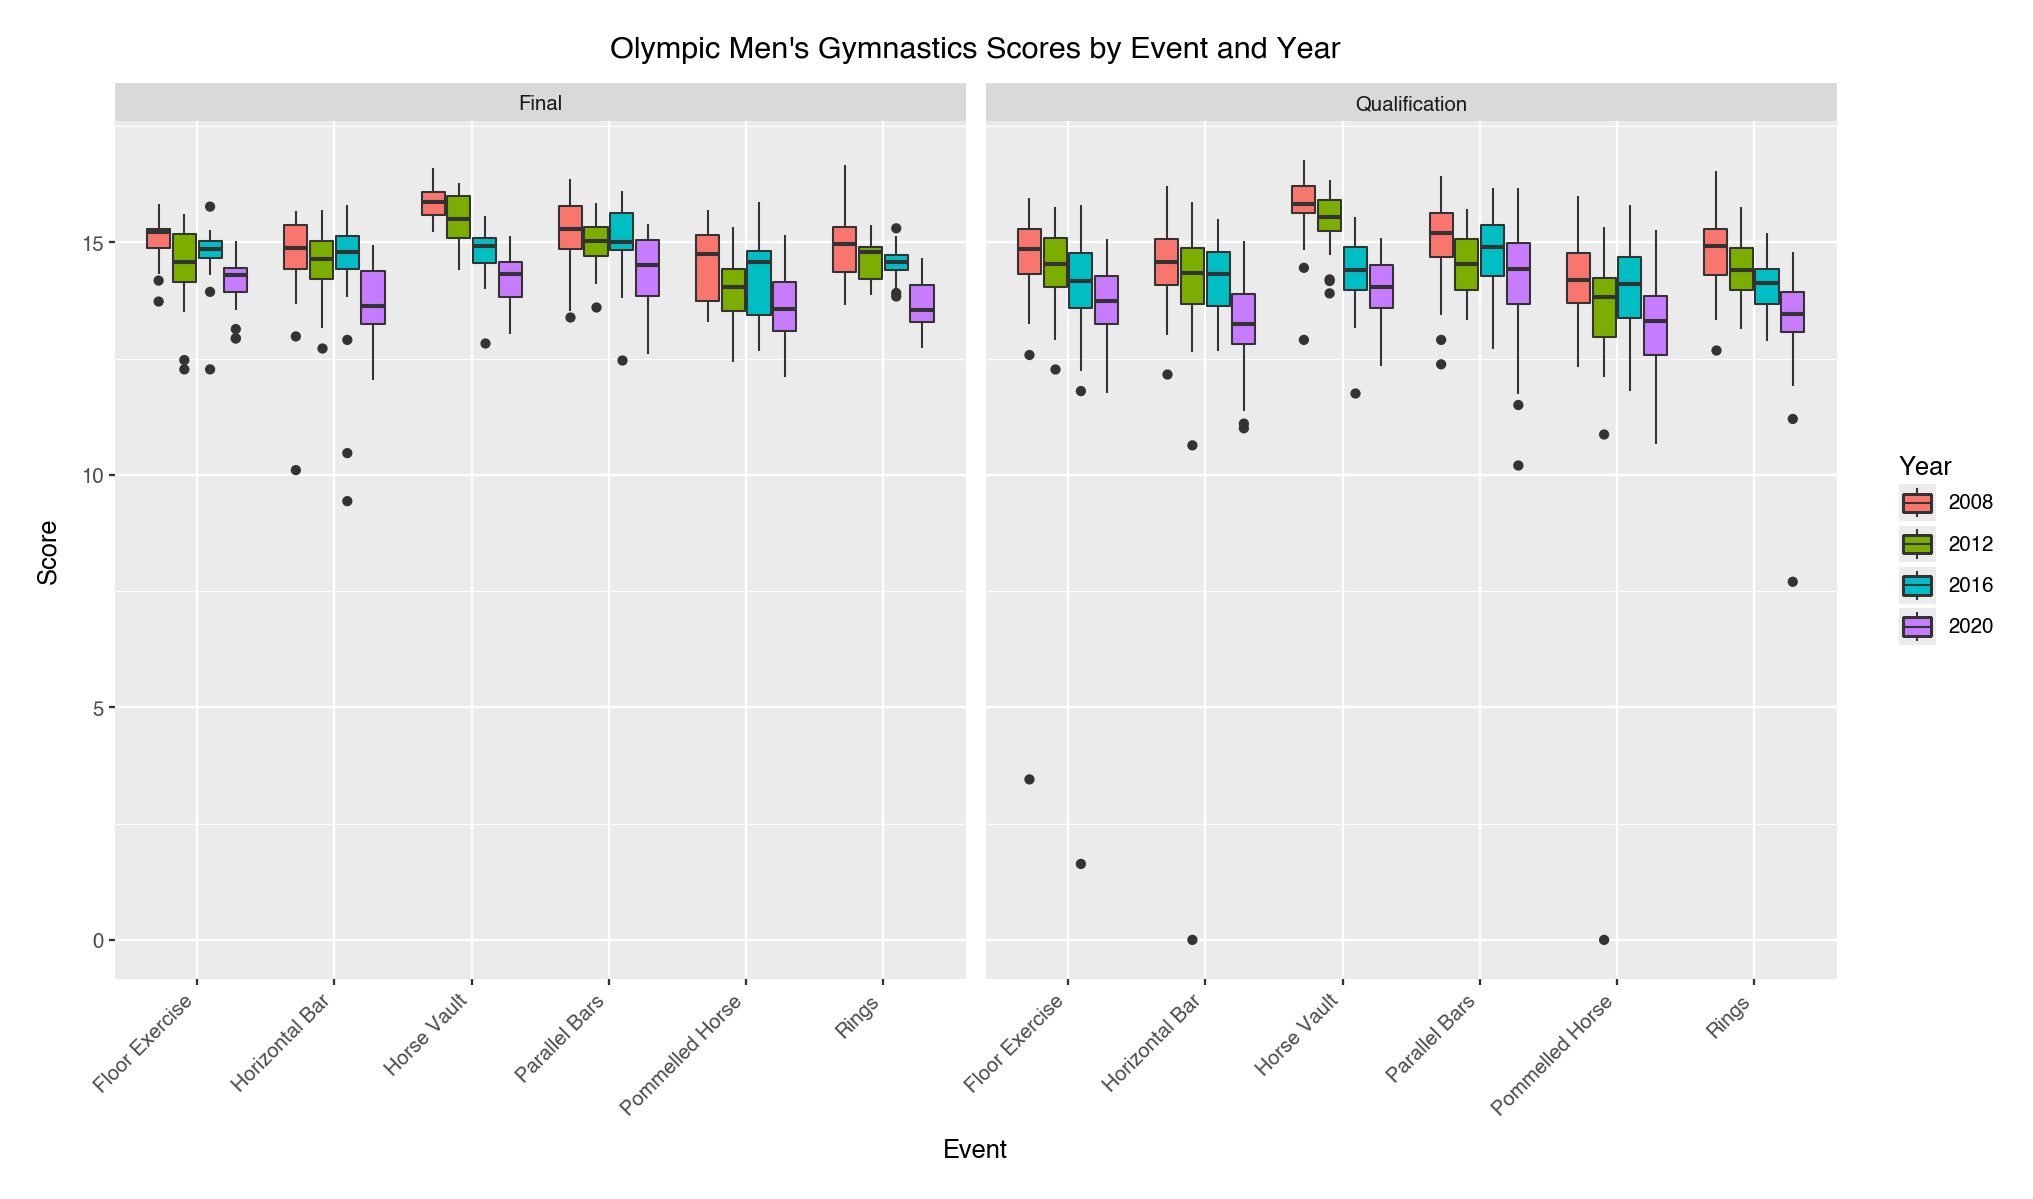

In [57]:
from plotnine import ggplot, aes, geom_boxplot, facet_wrap, labs, theme, element_text

olympics_plot = olympics_long.dropna(subset=["Score"]).copy()
olympics_plot["Year"] = olympics_plot["Year"].astype(str)

ggplot(olympics_plot, aes(x="Event", y="Score", fill="Year")) + geom_boxplot() + facet_wrap("Round") + labs(title="Olympic Men's Gymnastics Scores by Event and Year", x="Event", y="Score", fill="Year") + theme(axis_text_x=element_text(rotation=45, ha="right"), figure_size=(12, 7))

Answer: I used boxplots because they make it easier to compare the distributions of scores across different events and years. The colors represent the four Olympic years. I separated the final and qualification rounds into two panels so they are easier to compare. The line inside each box shows the median score, and the black points show unusually high or low scores.